Daily wikipedia *views*: Tesla, Elon Musk -- $tsla\_views_t, msk\_views_t$ \
Daily wikipedia *edits*: Tesla, Elon Musk -- $tsla\_edits_t, msk\_edits_t$ \
Market return proxy: SP500 close daily, -- $mkt\_return_t$ \
Google search: Tesla, Elon Musk, -- $tsla\_gsearch_t, msk\_gsearch_t$ \
Elon musk daily tweets: -- $msk\_tweets_t$

---


Each daily variable should be aligned with market open and close times, meaning we count occurences from yesterday, 16:00 up to today 16:00 ET.


| **Variable** | **Description** | **Source** | **Found or not?** |
| --- | --- | --- | --- |
| $tsla\_views_t$ | Daily Wikipedia page views for Tesla | `tesla-musk-views.csv` | True |
| $msk\_views_t$ | Daily Wikipedia page views for Elon Musk | `tesla-musk-views.csv` | True |
| $tsla\_edits_t$ | Daily Wikipedia edits for Tesla | Wikipedia | True |
| $msk\_edits_t$ | Daily Wikipedia edits for Elon Musk | Wikipedia | True |
| $mkt\_return_t$ | Daily market return proxy (S&P 500 close) | Financial market data | True |
| $tsla\_gsearch_t$ | Google search trends for Tesla | Google Trends | False |
| $msk\_gsearch_t$ | Google search trends for Elon Musk | Google Trends | False |
| $msk\_tweets_t$ | Daily tweets by Elon Musk | X (Twitter) API / dataset | True |

In [2]:
import pandas as pd
import importlib
import statsmodels.api as sm
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import edits_with_volume_plot as ewv
import numpy as np
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from ipywidgets import interact
_ = importlib.reload(ewv)

#### 1. Wikipedia per-page views: 
---

Wikipedia pageview data is aggregated on a UTC calendar-day basis; we align it to trading days defined by 16:00 ET close-to-close intervals, acknowledging minor temporal mismatch due to differing aggregation windows. Therefore, `views` dataframe below is sufficient as-is for analysis, aknowledging a minor mis-alignment

In [26]:
views = pd.read_csv("data/datasets/tesla-musk-views.csv")

In [27]:
views.set_index(pd.to_datetime(views.Date), inplace=True)
views.drop(columns=["Date"], inplace=True)

tsla_wiki_views = views["Tesla, Inc."]
msk_wiki_views = views["Elon Musk"]


In [28]:
msk_wiki_views

Date
2019-03-23    27257
2019-03-24    28666
2019-03-25    27867
2019-03-26    27929
2019-03-27    28664
              ...  
2026-04-17    15339
2026-04-18    15404
2026-04-19    15426
2026-04-20    16233
2026-04-21    15611
Name: Elon Musk, Length: 2587, dtype: int64

In [5]:
type(msk_wiki_views)

pandas.Series

#### 2. Daily Wikipedia edits for tesla and Elon Musk:
--- 

In [ ]:
wiki_tesla = pd.read_csv("data/datasets/WIKI_tesla.csv")
wiki_msk = pd.read_csv("data/datasets/WIKI_elon_musk.csv")

The following function was used to get aligned edit frequency of article aligned to a trading day window for consistent analysis:

In [51]:
def get_edit_freq(inp_df):
    df = inp_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["timestamp"] = df["timestamp"].dt.tz_convert("America/New_York")
    df["trading_day"] = pd.to_datetime((df["timestamp"] - pd.Timedelta(hours=16)).dt.date)
    return df.groupby("trading_day").size()

In [52]:
tsla_edits, msk_edits = get_edit_freq(wiki_tesla), get_edit_freq(wiki_msk)

#### 3. Market return proxy: sp500 close
--- 

Pretty straighforward as SP500 trading day is the same: from 16:00 ET one day to 16:00 ET another.

In [ ]:
sp500 = yf.download("^GSPC", start="2009-01-01")
sp500 = sp500[["Close"]]
sp500["mkt_return"] = np.log(sp500["Close"] / sp500["Close"].shift(1))
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,mkt_return
Ticker,^GSPC,
Date,,
2009-01-02,931.799988,NaN
2009-01-05,927.450012,-0.004679
2009-01-06,934.700012,0.007787
2009-01-07,906.650024,-0.030469
2009-01-08,909.729980,0.003391


#### 4. Tesla and Elon musk Google trends intensity
--- 

IMPOSSIBLE TO GET ON DAILY FREQUENCY!!!

#### 5. Number of tweets of Elon Musk
---

In [10]:
twtdf = pd.read_csv("data/datasets/all_musk_posts.csv")

/var/folders/tn/skq4_2sx25l_yltkmsj7kw400000gn/T/ipykernel_7541/3707703690.py:1: DtypeWarning: Columns (0: isReply, 1: isPinned, 2: isRetweet, 3: isQuote, 4: isConversationControlled) have mixed types. Specify dtype option on import or set low_memory=False.
  twtdf = pd.read_csv("data/datasets/all_musk_posts.csv")


The following script was executed to align Musk tweets with trading day windows

In [ ]:
twtdf["createdAt"] = pd.to_datetime(twtdf["createdAt"], utc=True)
twtdf["createdAt"] = twtdf["createdAt"].dt.tz_convert("America/New_York")
twtdf["trading_day"] = pd.to_datetime((twtdf["createdAt"] - pd.Timedelta(hours=16)).dt.date)
msk_tweets = twtdf.groupby("trading_day").size()

In [ ]:
for series in [mkt_return, msk_tweets, msk_edits, tsla_edits, tsla_wiki_views, msk_wiki_views]:
    series.index = (
    pd.to_datetime(series.index, utc=True)
    .tz_convert("America/New_York")
    .floor("D")
)

In [71]:
mkt_return = sp500.mkt_return

In [73]:
df = pd.concat([mkt_return, msk_tweets, msk_edits, tsla_edits, tsla_wiki_views, msk_wiki_views], axis=1, join="outer")
df.columns = ['mkt_return', "msk_tweets", "msk_edits", "tsla_edits", 'tsla_wiki_views', 'msk_wiki_views']
df.columns

/var/folders/tn/skq4_2sx25l_yltkmsj7kw400000gn/T/ipykernel_7541/3574210364.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([mkt_return, msk_tweets, msk_edits, tsla_edits, tsla_wiki_views, msk_wiki_views], axis=1, join="outer")


Index(['mkt_return', 'msk_tweets', 'msk_edits', 'tsla_edits',
       'tsla_wiki_views', 'msk_wiki_views'],
      dtype='str')

In [83]:
df.to_csv("major.csv")

In [99]:
subdf = df[df.index.year >= 2019]
subdf.isna().sum()

mkt_return          832
msk_tweets          470
msk_edits           830
tsla_edits         1280
tsla_wiki_views      81
msk_wiki_views       81
dtype: int64

In [104]:
subdf["tsla_edits"] = subdf["tsla_edits"].fillna(0)
subdf["msk_tweets"] = subdf["msk_tweets"].fillna(0)
subdf["msk_edits"] = subdf["msk_edits"].fillna(0)
# subdf["tsla_edits"] = subdf["tsla_edits"].fillna(0)
subdf.isna().sum()

mkt_return         832
msk_tweets           0
msk_edits            0
tsla_edits           0
tsla_wiki_views     81
msk_wiki_views      81
dtype: int64

In [107]:
subdf = subdf.dropna(subset=["mkt_return", "tsla_wiki_views", "msk_wiki_views"])


In [62]:
print(len(mkt_return))
print(len(msk_tweets))
print(len(msk_edits))
print(len(tsla_edits))
print(len(tsla_wiki_views))
print(len(msk_wiki_views))

print(len(set(mkt_return.index)
          & set(msk_tweets.index)
          & set(msk_edits.index)
          & set(tsla_wiki_views.index)))

4352
3463
3634
3316
2587
2587
1065


In [70]:
msk_wiki_views.index.dtype, tsla_wiki_views.index.dtype, msk_edits.index.dtype, tsla_edits.index.dtype, msk_tweets.index.dtype, mkt_return.index.dtype

(dtype('<M8[us]'),
 dtype('<M8[us]'),
 dtype('<M8[s]'),
 dtype('<M8[s]'),
 dtype('<M8[s]'),
 dtype('<M8[s]'))

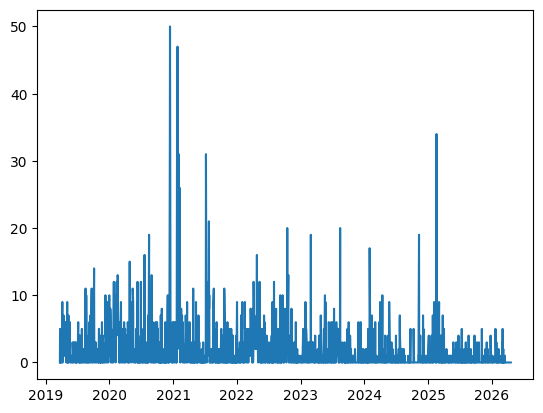